# HateXplain Binary Classification with Union Rationales

This notebook implements binary hate speech classification (Hate vs Normal) using the HateXplain methodology.
The rationale for each hate sample is the **union** of all moral foundation rationales.

## 1. Setup and Imports

In [ ]:
# Install required packages
!pip install transformers==4.44.0 datasets torch scikit-learn pandas numpy tqdm matplotlib seaborn --quiet

In [ ]:
import os
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizerFast,
    BertModel,
    BertPreTrainedModel,
    BertConfig,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    auc,
    confusion_matrix
)

from tqdm.auto import tqdm

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Using device: cuda


## 2. Configuration

In [ ]:
class Config:
    """Configuration for Binary HateXplain BERT model"""

    # Data paths
    DATA_PATH = 'hatebr_moralxplain.csv'
    MODEL_SAVE_PATH = '/content/drive/MyDrive/Rationale/models/'

    # Model configuration
    # MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'
    MODEL_NAME = 'google-bert/bert-base-multilingual-cased'
    MAX_LENGTH = 128

    # Binary classification: Normal vs Hate
    LABELS = ['Normal', 'Hate']
    NUM_LABELS = 2
    LABEL2ID = {'Normal': 0, 'Hate': 1}
    ID2LABEL = {0: 'Normal', 1: 'Hate'}

    # Moral foundation labels (for processing)
    MORAL_LABELS = ['HN', 'FN', 'PN', 'AN', 'LN']

    # Training configuration
    BATCH_SIZE = 16
    LEARNING_RATE = 2e-5
    NUM_EPOCHS = 20
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    PATIENCE = 3  # Early stopping patience

    # Attention supervision
    # LAMBDA_ATTENTION = 1.0
    LAMBDA_ATTENTION = 0.001
    TEMPERATURE = 2.0

    # Evaluation
    TOP_K_RATIONALES = 18
    THRESHOLD = 0.5

config = Config()
print(f"Labels: {config.LABELS}")
print(f"Number of labels: {config.NUM_LABELS}")

Labels: ['Normal', 'Hate']
Number of labels: 2


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create model save directory
os.makedirs(config.MODEL_SAVE_PATH, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Data Loading and Preprocessing

In [ ]:
# Load raw data
df = pd.read_csv(config.DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (7000, 16)
Columns: ['id', 'comment', 'annotator1_moralA', 'annotator1_moralA_rationales', 'annotator1_moralB', 'annotator1_moralB_rationales', 'annotator1_moralC', 'annotator1_moralC_rationales', 'annotator2_moralA', 'annotator2_moralA_rationales', 'annotator2_moralB', 'annotator2_moralB_rationales', 'annotator2_moralC', 'annotator2_moralC_rationales', 'offensive_label', 'link_post']


,id,comment,annotator1_moralA,annotator1_moralA_rationales,annotator1_moralB,annotator1_moralB_rationales,annotator1_moralC,annotator1_moralC_rationales,annotator2_moralA,annotator2_moralA_rationales,annotator2_moralB,annotator2_moralB_rationales,annotator2_moralC,annotator2_moralC_rationales,offensive_label,link_post
0,1,Mais um lixo,PN,Mais um lixo,0,0,0,0,PN,Mais um lixo,0,0,0,0,1,https://www.instagram.com/p/B2uThqdH9xI/
1,2,Essa nao tem vergonha na cara!!,HN,nao tem vergonha na cara!,0,0,0,0,FN,Essa nao tem vergonha na cara,0,0,0,0,1,https://www.instagram.com/p/B2uThqdH9xI/
2,3,Essa mulher é doente.pilantra!,FN,pilantra,0,0,0,0,FN,pilantra,0,0,0,0,1,https://www.instagram.com/p/B2uThqdH9xI/
3,4,Comunista safada...,PN,Comunista safada...,0,0,0,0,PN,safada,0,0,0,0,1,https://www.instagram.com/p/B2uThqdH9xI/
4,5,Vagabunda. Comunista. Mentirosa. O povo chilen...,FN,mentirosa;,PN,vagabunda; O povo chileno nao merece uma desgr...,AN,comunista,FN,Mentirosa,PN,vagabunda; O povo chileno nao merece uma desgr...,0,0,1,https://www.instagram.com/p/B2uThqdH9xI/


In [ ]:
def process_data_for_binary_classification(df, use_annotator=1):
    """
    Process data for binary classification (Hate vs Normal).
    Union all moral foundation rationales into a single hate rationale.

    Args:
        df: Raw dataframe
        use_annotator: Which annotator to use (1 or 2)

    Returns:
        Processed dataframe with binary labels and union rationales
    """
    processed_data = []
    moral_labels = config.MORAL_LABELS

    # Define annotator columns
    annotator_prefix = f'annotator{use_annotator}'
    moral_columns = [
        (f'{annotator_prefix}_moralA', f'{annotator_prefix}_moralA_rationales'),
        (f'{annotator_prefix}_moralB', f'{annotator_prefix}_moralB_rationales'),
        (f'{annotator_prefix}_moralC', f'{annotator_prefix}_moralC_rationales'),
    ]

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing data"):
        text = str(row['comment']).strip()

        if not text or text == 'nan':
            continue

        # Collect all moral labels and their rationales
        found_moral_labels = []
        all_rationale_texts = []

        for label_col, rationale_col in moral_columns:
            label = str(row.get(label_col, '0')).strip()
            rationale = str(row.get(rationale_col, '0')).strip()

            # Check if this is a valid moral label (HN, FN, PN, AN, LN)
            if label in moral_labels:
                found_moral_labels.append(label)

                # Collect rationale text if valid
                if rationale and rationale != '0' and rationale != 'nan':
                    # Split by semicolon if multiple rationales
                    rationale_parts = [r.strip() for r in rationale.split(';') if r.strip()]
                    all_rationale_texts.extend(rationale_parts)

        # Binary label: 1 if any moral foundation, 0 otherwise
        is_hate = len(found_moral_labels) > 0
        binary_label = 1 if is_hate else 0

        # Remove duplicate rationale texts
        all_rationale_texts = list(set(all_rationale_texts))

        processed_data.append({
            'id': row.get('id', idx),
            'text': text,
            'label': binary_label,
            'moral_labels': found_moral_labels,
            'rationale_texts': all_rationale_texts,
            'offensive_label': row.get('offensive_label', 0)
        })

    return pd.DataFrame(processed_data)


# Process data
processed_df = process_data_for_binary_classification(df, use_annotator=1)

print(f"\nProcessed dataset shape: {processed_df.shape}")
print(f"\nLabel distribution:")
print(processed_df['label'].value_counts())
print(f"\nHate: {(processed_df['label'] == 1).sum()}")
print(f"Normal: {(processed_df['label'] == 0).sum()}")

Processing data:   0%|          | 0/7000 [00:00<?, ?it/s]


Processed dataset shape: (7000, 6)

Label distribution:
label
0    3523
1    3477
Name: count, dtype: int64

Hate: 3477
Normal: 3523


In [ ]:
# Check some examples
print("=" * 60)
print("Example Hate samples with rationales:")
print("=" * 60)

hate_samples = processed_df[processed_df['label'] == 1].head(5)
for idx, row in hate_samples.iterrows():
    print(f"\nText: {row['text'][:100]}...")
    print(f"Moral Labels: {row['moral_labels']}")
    print(f"Rationale Texts: {row['rationale_texts']}")
    print("-" * 40)

Example Hate samples with rationales:

Text: Mais um lixo...
Moral Labels: ['PN']
Rationale Texts: ['Mais um lixo']
----------------------------------------

Text: Essa nao tem vergonha na cara!!...
Moral Labels: ['HN']
Rationale Texts: ['nao tem vergonha na cara!']
----------------------------------------

Text: Essa mulher é doente.pilantra!...
Moral Labels: ['FN']
Rationale Texts: ['pilantra']
----------------------------------------

Text: Comunista safada......
Moral Labels: ['PN']
Rationale Texts: ['Comunista safada...']
----------------------------------------

Text: Vagabunda. Comunista. Mentirosa. O povo chileno nao merece uma desgraça desta....
Moral Labels: ['FN', 'PN', 'AN']
Rationale Texts: ['comunista', 'O povo chileno nao merece uma desgraça desta', 'vagabunda', 'mentirosa']
----------------------------------------


## 4. Create Word-Level Rationale Masks

In [ ]:
def create_word_rationale_mask(text, rationale_texts):
    """
    Create a binary mask indicating which words are rationales.

    Args:
        text: Original text
        rationale_texts: List of rationale text spans

    Returns:
        List of 0/1 for each word (1 = rationale)
    """
    words = text.split()
    mask = [0] * len(words)

    if not rationale_texts:
        return mask

    # Normalize text for matching
    text_lower = text.lower()

    for rationale in rationale_texts:
        if not rationale:
            continue

        rationale_lower = rationale.lower().strip()
        rationale_words = rationale_lower.split()

        # Find rationale words in text
        for i, word in enumerate(words):
            word_lower = word.lower().strip('.,!?;:"\'')

            # Check if word is in any rationale
            for r_word in rationale_words:
                r_word_clean = r_word.strip('.,!?;:"\'')
                if r_word_clean and (word_lower == r_word_clean or r_word_clean in word_lower):
                    mask[i] = 1
                    break

    return mask


# Add rationale masks to dataframe
processed_df['rationale_mask'] = processed_df.apply(
    lambda row: create_word_rationale_mask(row['text'], row['rationale_texts']),
    axis=1
)

# Verify
print("Example rationale masks:")
for idx, row in processed_df[processed_df['label'] == 1].head(3).iterrows():
    words = row['text'].split()
    mask = row['rationale_mask']
    print(f"\nText: {row['text'][:80]}...")
    print(f"Rationale texts: {row['rationale_texts']}")
    rationale_words = [w for w, m in zip(words, mask) if m == 1]
    print(f"Rationale words: {rationale_words}")
    print(f"Mask: {mask[:15]}...")

Example rationale masks:

Text: Mais um lixo...
Rationale texts: ['Mais um lixo']
Rationale words: ['Mais', 'um', 'lixo']
Mask: [1, 1, 1]...

Text: Essa nao tem vergonha na cara!!...
Rationale texts: ['nao tem vergonha na cara!']
Rationale words: ['nao', 'tem', 'vergonha', 'na', 'cara!!']
Mask: [0, 1, 1, 1, 1, 1]...

Text: Essa mulher é doente.pilantra!...
Rationale texts: ['pilantra']
Rationale words: ['doente.pilantra!']
Mask: [0, 0, 0, 1]...


## 5. Train/Val/Test Split

In [ ]:
# Split data
train_data, temp_data = train_test_split(
    processed_df, test_size=0.2, random_state=42, stratify=processed_df['label']
)
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_data['label']
)

print(f"Train size: {len(train_data)}")
print(f"Val size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

print(f"\nTrain label distribution:")
print(train_data['label'].value_counts())

print(f"\nTest label distribution:")
print(test_data['label'].value_counts())

Train size: 5600
Val size: 700
Test size: 700

Train label distribution:
label
0    2818
1    2782
Name: count, dtype: int64

Test label distribution:
label
0    353
1    347
Name: count, dtype: int64


## 6. Tokenizer and Attention Generator

In [ ]:
# Load tokenizer
tokenizer = BertTokenizerFast.from_pretrained(config.MODEL_NAME)
print(f"Tokenizer loaded: {config.MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

Tokenizer loaded: google-bert/bert-base-multilingual-cased
Vocab size: 119547


In [ ]:
class AttentionGenerator:
    """
    Generate soft attention targets from word-level rationale masks.
    Maps word-level masks to subword token-level attention distributions.
    """

    def __init__(self, tokenizer, max_length, temperature=2.0):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.temperature = temperature

    def generate_attention(self, text, rationale_mask):
        """
        Generate attention distribution from rationale mask.

        Args:
            text: Original text
            rationale_mask: List of 0/1 for each word

        Returns:
            Tensor of attention weights (max_length,)
        """
        words = text.split()

        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_offsets_mapping=True,
            return_tensors='pt'
        )

        tokens = self.tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
        offsets = encoding['offset_mapping'][0].tolist()

        # Map word rationale to token rationale
        token_rationale = [0.0] * self.max_length

        # Build word boundaries
        word_starts = []
        current_pos = 0
        for word in words:
            # Find word in text
            idx = text.find(word, current_pos)
            if idx != -1:
                word_starts.append((idx, idx + len(word), len(word_starts)))
                current_pos = idx + len(word)

        # Assign rationale scores to tokens
        for token_idx, (start, end) in enumerate(offsets):
            if start == 0 and end == 0:  # Special token
                continue

            # Find which word this token belongs to
            for word_start, word_end, word_idx in word_starts:
                if start >= word_start and end <= word_end:
                    if word_idx < len(rationale_mask):
                        token_rationale[token_idx] = float(rationale_mask[word_idx])
                    break

        # Convert to soft attention using temperature
        token_rationale = torch.tensor(token_rationale)
        attention_mask = encoding['attention_mask'][0]

        # Apply temperature and normalize
        if token_rationale.sum() > 0:
            # Soft attention with temperature
            attention = token_rationale / self.temperature
            # Mask padding
            attention = attention * attention_mask.float()
            # Normalize to sum to 1
            if attention.sum() > 0:
                attention = attention / attention.sum()
            else:
                # Uniform if no rationale
                seq_len = attention_mask.sum().item()
                attention = attention_mask.float() / seq_len
        else:
            # Uniform attention for samples without rationale
            seq_len = attention_mask.sum().item()
            attention = attention_mask.float() / seq_len

        return attention


attention_generator = AttentionGenerator(tokenizer, config.MAX_LENGTH, config.TEMPERATURE)

## 7. Dataset Class

In [ ]:
class BinaryHateDataset(Dataset):
    """Dataset for binary hate classification with union rationales."""

    def __init__(self, data, tokenizer, attention_generator, max_length=128):
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.attention_generator = attention_generator
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        text = row['text']
        label = row['label']
        rationale_mask = row['rationale_mask']

        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Binary label (single value for BCE loss)
        label_tensor = torch.tensor(label, dtype=torch.float)

        # Generate attention target
        gt_attention = self.attention_generator.generate_attention(text, rationale_mask)

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': label_tensor,
            'gt_attention': gt_attention
        }


# Create datasets
train_dataset = BinaryHateDataset(train_data, tokenizer, attention_generator, config.MAX_LENGTH)
val_dataset = BinaryHateDataset(val_data, tokenizer, attention_generator, config.MAX_LENGTH)
test_dataset = BinaryHateDataset(test_data, tokenizer, attention_generator, config.MAX_LENGTH)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 350
Val batches: 44
Test batches: 44


In [ ]:
# Verify dataset
batch = next(iter(train_loader))
print("Batch shapes:")
for key, value in batch.items():
    print(f"  {key}: {value.shape}")

Batch shapes:
  input_ids: torch.Size([16, 128])
  attention_mask: torch.Size([16, 128])
  labels: torch.Size([16])
  gt_attention: torch.Size([16, 128])


## 8. Model Definition

In [ ]:
class BertForBinaryHateClassification(BertPreTrainedModel):
    """
    BERT model for binary hate classification with attention supervision.
    Uses CLS attention for explainability.
    """

    def __init__(self, config):
        super().__init__(config)
        self.bert = BertModel(config)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, 1)  # Binary output
        self.init_weights()

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        token_type_ids=None,
        labels=None,
        output_attentions=True,
        **kwargs
    ):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            output_attentions=output_attentions
        )

        # Get CLS token representation
        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)

        # Binary classification logits
        logits = self.classifier(pooled_output).squeeze(-1)

        # Extract CLS attention from last layer (average across heads)
        cls_attention = None
        if output_attentions and outputs.attentions is not None:
            last_layer_attention = outputs.attentions[-1]  # (batch, heads, seq, seq)
            cls_attention = last_layer_attention[:, :, 0, :].mean(dim=1)  # (batch, seq)

        return {
            'logits': logits,
            'cls_attention': cls_attention,
            'hidden_states': outputs.last_hidden_state
        }


# Initialize model
model = BertForBinaryHateClassification.from_pretrained(config.MODEL_NAME)
model.to(device)
print(f"Model loaded: {config.MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

Model loaded: google-bert/bert-base-multilingual-cased
Parameters: 177,854,209


## 9. Trainer Class

In [ ]:
class BinaryHateXplainTrainer:
    """
    Trainer for binary hate classification with attention supervision.
    """

    def __init__(self, model, device, lambda_attention=1.0):
        self.model = model
        self.device = device
        self.lambda_attention = lambda_attention

        # Binary cross entropy loss
        self.bce_loss = nn.BCEWithLogitsLoss()

    def compute_attention_loss(self, pred_attention, gt_attention, attention_mask):
        """
        KL divergence between predicted and ground truth attention.
        """
        # Normalize predictions
        pred_attention = pred_attention * attention_mask.float()
        pred_attention = pred_attention / (pred_attention.sum(dim=-1, keepdim=True) + 1e-10)

        # KL divergence
        gt_attention = gt_attention + 1e-10
        pred_attention = pred_attention + 1e-10

        kl_div = gt_attention * (torch.log(gt_attention) - torch.log(pred_attention))
        kl_div = kl_div * attention_mask.float()

        return kl_div.sum(dim=-1).mean()

    def train_step(self, batch, optimizer, use_attention_loss=True):
        """
        Single training step.
        """
        self.model.train()

        input_ids = batch['input_ids'].to(self.device)
        attention_mask = batch['attention_mask'].to(self.device)
        labels = batch['labels'].to(self.device)
        gt_attention = batch['gt_attention'].to(self.device)

        optimizer.zero_grad()

        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True
        )

        # Classification loss
        cls_loss = self.bce_loss(outputs['logits'], labels)

        # Attention loss
        total_loss = cls_loss
        attn_loss = torch.tensor(0.0)

        if use_attention_loss and outputs['cls_attention'] is not None:
            attn_loss = self.compute_attention_loss(
                outputs['cls_attention'], gt_attention, attention_mask
            )
            total_loss = cls_loss + self.lambda_attention * attn_loss

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        optimizer.step()

        return {
            'total_loss': total_loss.item(),
            'cls_loss': cls_loss.item(),
            'attn_loss': attn_loss.item() if isinstance(attn_loss, torch.Tensor) else attn_loss
        }

    def evaluate(self, data_loader, use_attention_loss=True):
        """
        Evaluate model on data loader.
        """
        self.model.eval()

        all_preds = []
        all_labels = []
        all_probs = []
        all_attentions = []
        all_gt_attentions = []
        total_loss = 0

        with torch.no_grad():
            for batch in tqdm(data_loader, desc="Evaluating"):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                gt_attention = batch['gt_attention'].to(self.device)

                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    output_attentions=True
                )

                # Loss
                cls_loss = self.bce_loss(outputs['logits'], labels)
                total_loss += cls_loss.item()

                # Predictions
                probs = torch.sigmoid(outputs['logits']).cpu().numpy()
                preds = (probs > 0.5).astype(int)

                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs)

                if outputs['cls_attention'] is not None:
                    all_attentions.extend(outputs['cls_attention'].cpu().numpy())
                    all_gt_attentions.extend(gt_attention.cpu().numpy())

        # Compute metrics
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)

        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='binary')

        try:
            auroc = roc_auc_score(all_labels, all_probs)
        except:
            auroc = 0.0

        return {
            'loss': total_loss / len(data_loader),
            'accuracy': accuracy,
            'f1': f1,
            'auroc': auroc,
            'predictions': all_preds,
            'labels': all_labels,
            'probs': all_probs,
            'attentions': all_attentions,
            'gt_attentions': all_gt_attentions
        }

## 10. Training Function

In [ ]:
def train_model(model, train_loader, val_loader, config, use_attention_loss=True, model_name="model"):
    """
    Train the model with early stopping.
    """
    trainer = BinaryHateXplainTrainer(model, device, config.LAMBDA_ATTENTION)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY
    )

    total_steps = len(train_loader) * config.NUM_EPOCHS
    warmup_steps = int(total_steps * config.WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer, warmup_steps, total_steps
    )

    best_f1 = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_auroc': []}

    for epoch in range(config.NUM_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{config.NUM_EPOCHS}")
        print("=" * 50)

        # Training
        model.train()
        epoch_loss = 0

        pbar = tqdm(train_loader, desc="Training")
        for batch in pbar:
            losses = trainer.train_step(batch, optimizer, use_attention_loss)
            scheduler.step()

            epoch_loss += losses['total_loss']
            pbar.set_postfix({'loss': f"{losses['total_loss']:.4f}"})

        avg_train_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # Validation
        val_results = trainer.evaluate(val_loader, use_attention_loss)
        history['val_loss'].append(val_results['loss'])
        history['val_f1'].append(val_results['f1'])
        history['val_auroc'].append(val_results['auroc'])

        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {val_results['loss']:.4f}")
        print(f"Val Accuracy: {val_results['accuracy']:.4f}")
        print(f"Val F1: {val_results['f1']:.4f}")
        print(f"Val AUROC: {val_results['auroc']:.4f}")

        # Early stopping
        if val_results['f1'] > best_f1:
            best_f1 = val_results['f1']
            patience_counter = 0

            # Save best model
            save_path = os.path.join(config.MODEL_SAVE_PATH, f'{model_name}_best.pt')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_f1': best_f1,
            }, save_path)
            print(f"Best model saved: {save_path}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{config.PATIENCE}")

            if patience_counter >= config.PATIENCE:
                print("Early stopping triggered!")
                break

    return trainer, history

## 11. Train Baseline Model (No Attention Supervision)

In [ ]:
print("="*60)
print("Training BERT Baseline (No Attention Supervision)")
print("="*60)

# Initialize fresh model
model_baseline = BertForBinaryHateClassification.from_pretrained(config.MODEL_NAME)
model_baseline.to(device)

# Train without attention loss
trainer_baseline, history_baseline = train_model(
    model_baseline, train_loader, val_loader, config,
    use_attention_loss=False,
    model_name="bert_binary_baseline_mbert"
)

Training BERT Baseline (No Attention Supervision)


Some weights of BertForBinaryHateClassification were not initialized from the model checkpoint at google-bert/bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train Loss: 0.0264
Val Loss: 0.8637
Val Accuracy: 0.8771
Val F1: 0.8778
Val AUROC: 0.9473
No improvement. Patience: 2/3

Epoch 11/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train Loss: 0.0177
Val Loss: 0.9740
Val Accuracy: 0.8714
Val F1: 0.8770
Val AUROC: 0.9481
No improvement. Patience: 3/3
Early stopping triggered!


## 12. Train HateXplain Model (With Attention Supervision)

In [ ]:
print("="*60)
print("Training BERT-HateXplain (With Attention Supervision)")
print("="*60)

# Initialize fresh model
model_hatexplain = BertForBinaryHateClassification.from_pretrained(config.MODEL_NAME)
model_hatexplain.to(device)

# Train with attention loss
trainer_hatexplain, history_hatexplain = train_model(
    model_hatexplain, train_loader, val_loader, config,
    use_attention_loss=True,
    model_name="bert_binary_hatexplain_timbau_0point001"
)

Training BERT-HateXplain (With Attention Supervision)


Some weights of BertForBinaryHateClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


...

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train Loss: 0.0187
Val Loss: 0.5334
Val Accuracy: 0.9200
Val F1: 0.9174
Val AUROC: 0.9681
No improvement. Patience: 2/3

Epoch 8/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train Loss: 0.0095
Val Loss: 0.5222
Val Accuracy: 0.9257
Val F1: 0.9242
Val AUROC: 0.9762
No improvement. Patience: 3/3
Early stopping triggered!


## 13. Evaluation Metrics

In [ ]:
class PlausibilityMetrics:
    """Compute plausibility metrics for attention explanations."""

    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def compute_iou_f1(self, pred_attention, gt_attention, threshold=None):
        """Compute IOU F1 between predicted and ground truth attention."""
        if threshold is None:
            threshold = self.threshold

        # Binarize
        pred_binary = (pred_attention > np.mean(pred_attention)).astype(int)
        gt_binary = (gt_attention > np.mean(gt_attention)).astype(int)

        # IOU
        intersection = np.sum(pred_binary & gt_binary)
        union = np.sum(pred_binary | gt_binary)

        if union == 0:
            return 0.0

        iou = intersection / union
        return iou

    def compute_token_f1(self, pred_attention, gt_attention):
        """Compute token-level F1."""
        pred_binary = (pred_attention > np.mean(pred_attention)).astype(int)
        gt_binary = (gt_attention > np.mean(gt_attention)).astype(int)

        tp = np.sum(pred_binary & gt_binary)
        fp = np.sum(pred_binary & ~gt_binary)
        fn = np.sum(~pred_binary & gt_binary)

        precision = tp / (tp + fp + 1e-10)
        recall = tp / (tp + fn + 1e-10)
        f1 = 2 * precision * recall / (precision + recall + 1e-10)

        return f1

    def compute_auprc(self, pred_attention, gt_attention):
        """Compute Area Under Precision-Recall Curve."""
        gt_binary = (gt_attention > np.mean(gt_attention)).astype(int)

        if gt_binary.sum() == 0 or gt_binary.sum() == len(gt_binary):
            return 0.0

        try:
            precision, recall, _ = precision_recall_curve(gt_binary, pred_attention)
            return auc(recall, precision)
        except:
            return 0.0

    def compute_all(self, pred_attentions, gt_attentions):
        """Compute all plausibility metrics."""
        iou_scores = []
        token_f1_scores = []
        auprc_scores = []

        for pred, gt in zip(pred_attentions, gt_attentions):
            iou_scores.append(self.compute_iou_f1(pred, gt))
            token_f1_scores.append(self.compute_token_f1(pred, gt))
            auprc_scores.append(self.compute_auprc(pred, gt))

        return {
            'iou_f1': np.mean(iou_scores),
            'token_f1': np.mean(token_f1_scores),
            'auprc': np.mean(auprc_scores)
        }


plausibility = PlausibilityMetrics()

In [ ]:
class FaithfulnessMetrics:
    """Compute faithfulness metrics (comprehensiveness and sufficiency)."""

    def __init__(self, model, tokenizer, device, top_k=18, threshold=0.5, min_k=5):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.top_k = top_k
        self.threshold = threshold
        self.min_k = min_k
        self.mask_token_id = tokenizer.mask_token_id

    def select_rationale_indices(self, attention_weights, attention_mask):
        """Select top-k attention indices as rationales."""
        valid_attention = attention_weights.copy()
        valid_attention[attention_mask == 0] = -np.inf
        valid_attention[0] = -np.inf  # [CLS]

        seq_len = int(attention_mask.sum())
        valid_attention[seq_len - 1] = -np.inf  # [SEP]

        k = min(self.top_k, seq_len - 2)
        k = max(self.min_k, k)

        indices = valid_attention.argsort()[-k:][::-1]
        indices = [i for i in indices if valid_attention[i] > -np.inf]

        return np.array(indices)

    def get_prediction_prob(self, input_ids, attention_mask):
        """Get prediction probability."""
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False
            )
            prob = torch.sigmoid(outputs['logits']).item()
        return prob

    def create_masked_input(self, input_ids, indices_to_mask):
        """Replace indices with [MASK]."""
        masked_ids = input_ids.clone()
        for idx in indices_to_mask:
            if 0 < idx < len(masked_ids) - 1:
                masked_ids[idx] = self.mask_token_id
        return masked_ids

    def create_rationale_only_input(self, input_ids, attention_mask, rationale_indices):
        """Create input with only rationale tokens."""
        seq_len = int(attention_mask.sum())
        rationale_set = set(rationale_indices.tolist())

        new_ids = [self.tokenizer.cls_token_id]
        for idx in range(1, seq_len - 1):
            if idx in rationale_set:
                new_ids.append(input_ids[idx].item())
        new_ids.append(self.tokenizer.sep_token_id)

        new_len = len(new_ids)
        while len(new_ids) < len(input_ids):
            new_ids.append(self.tokenizer.pad_token_id)

        new_input_ids = torch.tensor(new_ids, dtype=input_ids.dtype)
        new_attention_mask = torch.zeros_like(attention_mask)
        new_attention_mask[:new_len] = 1

        return new_input_ids, new_attention_mask

    def compute_all(self, data_loader, attentions):
        """Compute comprehensiveness and sufficiency."""
        comp_scores = []
        suff_scores = []
        self.model.eval()
        idx = 0

        for batch in tqdm(data_loader, desc='Computing Faithfulness'):
            batch_size = batch['input_ids'].size(0)

            for i in range(batch_size):
                if idx >= len(attentions):
                    break

                input_ids = batch['input_ids'][i]
                attention_mask = batch['attention_mask'][i]
                attention_weights = attentions[idx]

                # Original probability
                orig_prob = self.get_prediction_prob(input_ids, attention_mask)

                # Select rationales
                rationale_indices = self.select_rationale_indices(
                    attention_weights, attention_mask.numpy()
                )

                if len(rationale_indices) == 0:
                    idx += 1
                    continue

                # Comprehensiveness: mask rationales
                masked_ids = self.create_masked_input(input_ids, rationale_indices)
                masked_prob = self.get_prediction_prob(masked_ids, attention_mask)
                comp = orig_prob - masked_prob

                # Sufficiency: keep only rationales
                rationale_ids, rationale_mask = self.create_rationale_only_input(
                    input_ids, attention_mask, rationale_indices
                )
                rationale_prob = self.get_prediction_prob(rationale_ids, rationale_mask)
                suff = orig_prob - rationale_prob

                comp_scores.append(comp)
                suff_scores.append(suff)
                idx += 1

        return {
            'comprehensiveness': np.mean(comp_scores) if comp_scores else 0.0,
            'sufficiency': np.mean(suff_scores) if suff_scores else 0.0,
            'num_samples': len(comp_scores)
        }

## 14. Full Evaluation Function

In [ ]:
def evaluate_model(trainer, test_loader, tokenizer, model_name, use_attention_loss=True):
    """Full evaluation of model."""
    print(f"\n{'='*60}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*60}\n")

    # Basic evaluation
    results = trainer.evaluate(test_loader, use_attention_loss)

    print("Performance Metrics:")
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  F1 Score: {results['f1']:.4f}")
    print(f"  AUROC: {results['auroc']:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(
        results['labels'],
        results['predictions'],
        target_names=config.LABELS,
        digits=4
    ))

    # Plausibility metrics
    if len(results['attentions']) > 0 and len(results['gt_attentions']) > 0:
        plaus_results = plausibility.compute_all(results['attentions'], results['gt_attentions'])
        print(f"\nPlausibility Metrics:")
        print(f"  IOU F1: {plaus_results['iou_f1']:.4f}")
        print(f"  Token F1: {plaus_results['token_f1']:.4f}")
        print(f"  AUPRC: {plaus_results['auprc']:.4f}")
    else:
        plaus_results = {'iou_f1': 0, 'token_f1': 0, 'auprc': 0}

    # Faithfulness metrics
    faith_calc = FaithfulnessMetrics(trainer.model, tokenizer, device, top_k=18, min_k=5)
    faith_results = faith_calc.compute_all(test_loader, results['attentions'])
    print(f"\nFaithfulness Metrics:")
    print(f"  Comprehensiveness: {faith_results['comprehensiveness']:.4f} (↑ better)")
    print(f"  Sufficiency: {faith_results['sufficiency']:.4f} (↓ better)")

    # Summary
    print(f"\n{'='*60}")
    print(f"SUMMARY: {model_name}")
    print(f"{'='*60}")
    print(f"Performance: Acc={results['accuracy']:.4f}, F1={results['f1']:.4f}, AUROC={results['auroc']:.4f}")
    print(f"Plausibility: IOU F1={plaus_results['iou_f1']:.4f}, Token F1={plaus_results['token_f1']:.4f}")
    print(f"Faithfulness: Comp={faith_results['comprehensiveness']:.4f}, Suff={faith_results['sufficiency']:.4f}")

    return {
        'performance': {
            'accuracy': results['accuracy'],
            'f1': results['f1'],
            'auroc': results['auroc']
        },
        'plausibility': plaus_results,
        'faithfulness': faith_results,
        'predictions': results['predictions'],
        'labels': results['labels']
    }

## 15. Evaluate Both Models

In [ ]:
# Evaluate Baseline
eval_baseline = evaluate_model(
    trainer_baseline, test_loader, tokenizer,
    "BERT-Baseline", use_attention_loss=False
)

NameError: name 'trainer_baseline' is not defined

In [ ]:
# Evaluate HateXplain
eval_hatexplain = evaluate_model(
    trainer_hatexplain, test_loader, tokenizer,
    "BERT-HateXplain", use_attention_loss=True
)


Evaluation: BERT-HateXplain



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance Metrics:
  Accuracy: 0.9086
  F1 Score: 0.9080
  AUROC: 0.9686

Classification Report:
              precision    recall  f1-score   support

      Normal     0.9117    0.9065    0.9091       353
        Hate     0.9054    0.9107    0.9080       347

    accuracy                         0.9086       700
   macro avg     0.9086    0.9086    0.9086       700
weighted avg     0.9086    0.9086    0.9086       700


Plausibility Metrics:
  IOU F1: 0.8590
  Token F1: 0.9104
  AUPRC: 0.9551


Computing Faithfulness:   0%|          | 0/44 [00:00<?, ?it/s]


Faithfulness Metrics:
  Comprehensiveness: -0.4817 (↑ better)
  Sufficiency: -0.0278 (↓ better)

SUMMARY: BERT-HateXplain
Performance: Acc=0.9086, F1=0.9080, AUROC=0.9686
Plausibility: IOU F1=0.8590, Token F1=0.9104
Faithfulness: Comp=-0.4817, Suff=-0.0278


## 16. Compare Results

In [ ]:
def print_comparison(results_dict):
    """Print comparison table."""
    print("\n" + "="*90)
    print("RESULTS COMPARISON")
    print("="*90)

    print(f"\n{'Model':<20} | {'Acc':<7} | {'F1':<7} | {'AUROC':<7} | {'IOU F1':<7} | {'Tok F1':<7} | {'Comp':<7} | {'Suff':<7}")
    print("-"*90)

    for name, res in results_dict.items():
        perf = res['performance']
        plaus = res['plausibility']
        faith = res['faithfulness']

        print(f"{name:<20} | {perf['accuracy']:.4f}  | {perf['f1']:.4f}  | {perf['auroc']:.4f}  | "
              f"{plaus['iou_f1']:.4f}  | {plaus['token_f1']:.4f}  | "
              f"{faith['comprehensiveness']:.4f}  | {faith['sufficiency']:.4f}")


all_results = {
    'BERT-Baseline': eval_baseline,
    'BERT-HateXplain': eval_hatexplain
}

print_comparison(all_results)


RESULTS COMPARISON

Model                | Acc     | F1      | AUROC   | IOU F1  | Tok F1  | Comp    | Suff   
------------------------------------------------------------------------------------------
BERT-Baseline        | 0.9029  | 0.8988  | 0.9586  | 0.7876  | 0.8625  | -0.5148  | -0.0215
BERT-HateXplain      | 0.9157  | 0.9136  | 0.9537  | 0.9171  | 0.9468  | -0.5007  | -0.0269


## 17. Visualize Training History

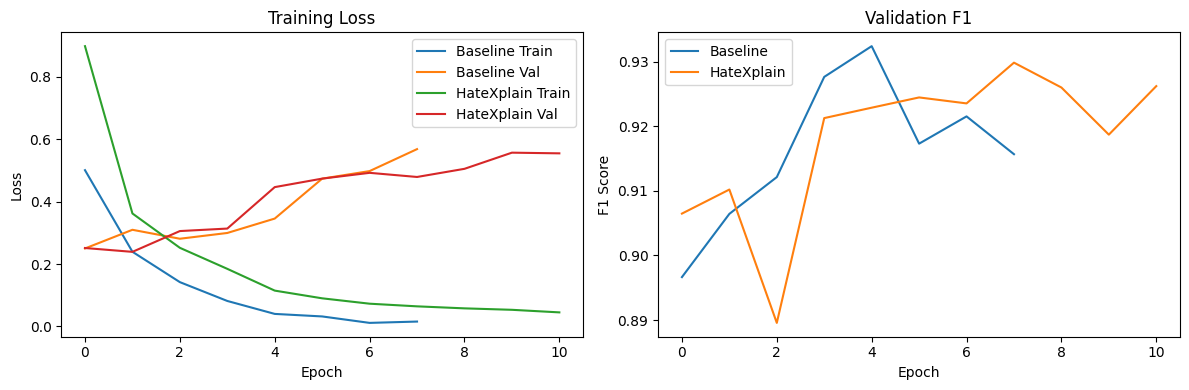

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history_baseline['train_loss'], label='Baseline Train')
axes[0].plot(history_baseline['val_loss'], label='Baseline Val')
axes[0].plot(history_hatexplain['train_loss'], label='HateXplain Train')
axes[0].plot(history_hatexplain['val_loss'], label='HateXplain Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()

# F1
axes[1].plot(history_baseline['val_f1'], label='Baseline')
axes[1].plot(history_hatexplain['val_f1'], label='HateXplain')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Validation F1')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(config.MODEL_SAVE_PATH, 'training_history.png'), dpi=300)
plt.show()

## 18. Confusion Matrix

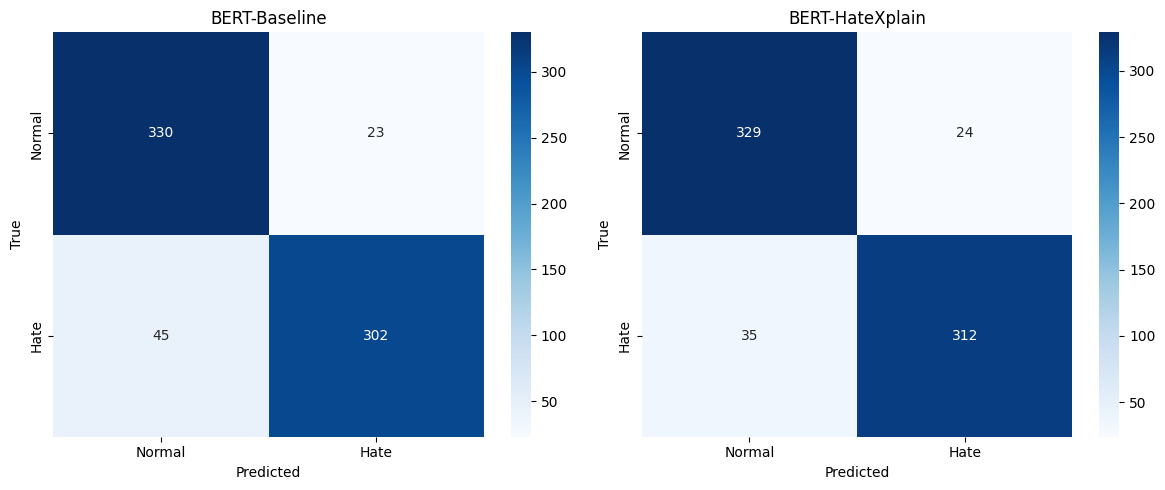

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, res) in zip(axes, all_results.items()):
    cm = confusion_matrix(res['labels'], res['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=config.LABELS, yticklabels=config.LABELS)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{name}')

plt.tight_layout()
plt.savefig(os.path.join(config.MODEL_SAVE_PATH, 'confusion_matrices.png'), dpi=300)
plt.show()

## 19. Save Results

In [ ]:
# Save results to CSV
results_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': res['performance']['accuracy'],
        'F1': res['performance']['f1'],
        'AUROC': res['performance']['auroc'],
        'IOU_F1': res['plausibility']['iou_f1'],
        'Token_F1': res['plausibility']['token_f1'],
        'AUPRC': res['plausibility']['auprc'],
        'Comprehensiveness': res['faithfulness']['comprehensiveness'],
        'Sufficiency': res['faithfulness']['sufficiency']
    }
    for name, res in all_results.items()
])

results_df.to_csv(os.path.join(config.MODEL_SAVE_PATH, 'binary_classification_results_mbert.csv'), index=False)
print("Results saved!")
results_df

Results saved!


,Model,Accuracy,F1,AUROC,IOU_F1,Token_F1,AUPRC,Comprehensiveness,Sufficiency
0,BERT-Baseline,0.902857,0.898810,0.958642,0.787594,0.862504,0.824523,-0.514797,-0.021472
1,BERT-HateXplain,0.915714,0.913616,0.953703,0.917146,0.946790,0.978098,-0.500665,-0.026878


## 20. Example Predictions with Attention Visualization

In [ ]:
def visualize_attention(model, tokenizer, text, device):
    """Visualize attention for a single text."""
    model.eval()

    encoding = tokenizer(
        text,
        max_length=config.MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    with torch.no_grad():
        outputs = model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device),
            output_attentions=True
        )

    prob = torch.sigmoid(outputs['logits']).item()
    pred = "Hate" if prob > 0.5 else "Normal"

    attention = outputs['cls_attention'][0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
    seq_len = encoding['attention_mask'].sum().item()

    print(f"Text: {text}")
    print(f"Prediction: {pred} (prob={prob:.4f})")
    print(f"\nTop attended tokens:")

    # Get top tokens
    token_attn = [(tokens[i], attention[i]) for i in range(1, seq_len-1)]
    token_attn.sort(key=lambda x: x[1], reverse=True)

    for token, attn in token_attn[:10]:
        print(f"  {token}: {attn:.4f}")

    return prob, pred, attention


# Test examples
test_texts = [
    "Esse político é um ladrão corrupto!",
    "Bom dia, espero que tenha um ótimo dia.",
    "Essa gente não presta, são todos vagabundos."
]

print("="*60)
print("Example Predictions (HateXplain Model)")
print("="*60)

for text in test_texts:
    print("\n" + "-"*40)
    visualize_attention(model_hatexplain, tokenizer, text, device)

Example Predictions (HateXplain Model)

----------------------------------------
Text: Esse político é um ladrão corrupto!
Prediction: Hate (prob=0.9996)

Top attended tokens:
  ##up: 0.1101
  corr: 0.1066
  ##to: 0.1057
  lad: 0.1053
  ##rão: 0.1044
  um: 0.0975
  Esse: 0.0948
  !: 0.0945
  político: 0.0920
  é: 0.0887

----------------------------------------
Text: Bom dia, espero que tenha um ótimo dia.
Prediction: Normal (prob=0.0001)

Top attended tokens:
  esper: 0.0791
  ,: 0.0784
  que: 0.0780
  ##o: 0.0779
  ótimo: 0.0771
  .: 0.0770
  um: 0.0769
  Bom: 0.0768
  tenha: 0.0767
  dia: 0.0762

----------------------------------------
Text: Essa gente não presta, são todos vagabundos.
Prediction: Hate (prob=0.9994)

Top attended tokens:
  ##dos: 0.0873
  ##bun: 0.0871
  vaga: 0.0871
  não: 0.0859
  todos: 0.0859
  ##ta: 0.0859
  Essa: 0.0851
  pres: 0.0850
  são: 0.0843
  gente: 0.0841


## Summary

This notebook implements:

1. **Binary Classification**: Hate vs Normal (instead of multi-label moral foundations)
2. **Union Rationales**: All moral foundation rationales combined into single hate rationale
3. **Attention Supervision**: HateXplain methodology with KL divergence loss
4. **Evaluation Metrics**:
   - Performance: Accuracy, F1, AUROC
   - Plausibility: IOU F1, Token F1, AUPRC
   - Faithfulness: Comprehensiveness, Sufficiency

Expected results show HateXplain model should have:
- Similar or better classification performance
- Higher plausibility (attention aligns with rationales)
- Higher faithfulness (attention is actually used for predictions)

In [ ]:
class BiasMetricsBinary:
    """
    Compute bias metrics for binary classification.
    Since we don't have target communities, we measure bias across
    different prediction confidence levels or text characteristics.
    """

    def __init__(self):
        pass

    def compute_subgroup_auc(self, y_true, y_pred, subgroup_mask):
        """AUC within subgroup."""
        if subgroup_mask.sum() < 10:
            return None

        y_sub = y_true[subgroup_mask]
        y_pred_sub = y_pred[subgroup_mask]

        if len(np.unique(y_sub)) < 2:
            return None

        try:
            return roc_auc_score(y_sub, y_pred_sub)
        except:
            return None

    def compute_bpsn_auc(self, y_true, y_pred, subgroup_mask):
        """Background Positive, Subgroup Negative."""
        bg_pos = (y_true == 1) & (~subgroup_mask)
        sub_neg = (y_true == 0) & subgroup_mask

        if bg_pos.sum() < 5 or sub_neg.sum() < 5:
            return None

        combined = bg_pos | sub_neg
        y_combined = y_true[combined]
        y_pred_combined = y_pred[combined]

        if len(np.unique(y_combined)) < 2:
            return None

        try:
            return roc_auc_score(y_combined, y_pred_combined)
        except:
            return None

    def compute_bnsp_auc(self, y_true, y_pred, subgroup_mask):
        """Background Negative, Subgroup Positive."""
        bg_neg = (y_true == 0) & (~subgroup_mask)
        sub_pos = (y_true == 1) & subgroup_mask

        if bg_neg.sum() < 5 or sub_pos.sum() < 5:
            return None

        combined = bg_neg | sub_pos
        y_combined = y_true[combined]
        y_pred_combined = y_pred[combined]

        if len(np.unique(y_combined)) < 2:
            return None

        try:
            return roc_auc_score(y_combined, y_pred_combined)
        except:
            return None

    def power_mean(self, values, p=-5):
        """Generalized mean with p=-5."""
        values = [v for v in values if v is not None]
        if not values:
            return None
        values = np.array(values)
        return np.power(np.mean(np.power(values, p)), 1/p)

    def compute_all(self, y_true, y_pred_proba, texts):
        """
        Compute bias using text-based subgroups.
        """
        # Define Portuguese identity term groups
        # identity_groups = {
        #     'gender': ['mulher', 'mulheres', 'homem', 'homens', 'feminista',
        #               'gay', 'lésbica', 'trans', 'viado', 'sapatão'],
        #     'race': ['negro', 'negra', 'preto', 'preta', 'branco', 'branca',
        #             'índio', 'indígena', 'macaco'],
        #     'politics': ['bolsonaro', 'lula', 'petista', 'comunista',
        #                 'fascista', 'esquerdista', 'direitista'],
        #     'religion': ['cristão', 'evangélico', 'católico', 'ateu',
        #                 'macumbeiro', 'crente']
        # }
        identity_groups = {
              "female_gender": ["mulher", "mulheres", "vagabunda", "quenga", "puta", "vadia", "piranha", "feminista", "bruxa", "ninfeta", "rapariga", "cachorra", "cachorrona", "quenga", "galinha", "cadela"],
              "male_gender": ["homem", "homens", "viado", "bicha", "maricas"],
              "race_ethnicity": ["preto", "negra", "negão", "branco", "racista", "macaco", "macaca", "chita", "nordestino", "nordestinos", "judeu", "jornazista", "hipocristão", "macumbeira", "macumbeiro", "pastor"],
              "sexual_orientation": ["gay", "viado", "lésbica", "sapatão", "homossexual", "sapatona", "bicha", "veado"],
              "political_identity": ["comunista", "socialista", "esquerdista", "bolsonarista", "petista", "fascista", "petralha", "esquerda", "direita", "socialista", "bozo", "minions", "chauvinista", "petzadas", "ptzada", "pretalhas", "vermelhada"],
              "fatphobia": ["peppa", "pepa", "pepinha", "gorda", "gordo", "barriguda", "barrigudo", "porca", "porco", "roliça", "roliço", "vaca", "boi"],
              }

        results = {'per_group': {}}
        all_sub_aucs = []
        all_bpsn_aucs = []
        all_bnsp_aucs = []

        y_true = np.array(y_true)
        y_pred_proba = np.array(y_pred_proba)

        for group_name, terms in identity_groups.items():
            # Create subgroup mask
            mask = np.array([
                any(term in text.lower() for term in terms)
                for text in texts
            ])

            n_in_group = mask.sum()
            if n_in_group < 1:
                print(f"  {group_name}: Skipped (only {n_in_group} samples)")
                continue

            sub_auc = self.compute_subgroup_auc(y_true, y_pred_proba, mask)
            bpsn_auc = self.compute_bpsn_auc(y_true, y_pred_proba, mask)
            bnsp_auc = self.compute_bnsp_auc(y_true, y_pred_proba, mask)

            results['per_group'][group_name] = {
                'n_samples': int(n_in_group),
                'subgroup_auc': sub_auc,
                'bpsn_auc': bpsn_auc,
                'bnsp_auc': bnsp_auc
            }

            if sub_auc is not None:
                all_sub_aucs.append(sub_auc)
            if bpsn_auc is not None:
                all_bpsn_aucs.append(bpsn_auc)
            if bnsp_auc is not None:
                all_bnsp_aucs.append(bnsp_auc)

            sub_str = f"{sub_auc:.4f}" if sub_auc else "N/A"
            bpsn_str = f"{bpsn_auc:.4f}" if bpsn_auc else "N/A"
            bnsp_str = f"{bnsp_auc:.4f}" if bnsp_auc else "N/A"
            print(f"  {group_name}: n={n_in_group}, SubAUC={sub_str}, BPSN={bpsn_str}, BNSP={bnsp_str}")

        results['GMB_Subgroup'] = self.power_mean(all_sub_aucs)
        results['GMB_BPSN'] = self.power_mean(all_bpsn_aucs)
        results['GMB_BNSP'] = self.power_mean(all_bnsp_aucs)

        return results


class FaithfulnessMetrics:
    """Updated faithfulness with rationale-only input (not masking)."""

    def __init__(self, model, tokenizer, device, top_k=18, threshold=0.5, min_k=10):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.top_k = top_k
        self.threshold = threshold
        self.min_k = min_k
        self.mask_token_id = tokenizer.mask_token_id
        self.pad_token_id = tokenizer.pad_token_id
        self.cls_token_id = tokenizer.cls_token_id
        self.sep_token_id = tokenizer.sep_token_id

    def select_rationale_indices(self, attention_weights, attention_mask, gt_attention=None, method='topk'):
        """Select rationale indices."""
        valid_attention = attention_weights.copy()
        valid_attention[attention_mask == 0] = -np.inf
        valid_attention[0] = -np.inf  # [CLS]

        seq_len = int(attention_mask.sum())
        valid_attention[seq_len - 1] = -np.inf  # [SEP]

        valid_count = seq_len - 2

        if method == 'adaptive' and gt_attention is not None:
            # Match ground truth rationale count
            uniform_val = 1.0 / seq_len
            k = int((gt_attention > uniform_val * 1.5).sum())
            k = max(self.min_k, min(k, valid_count))
        else:
            k = min(self.top_k, valid_count)

        k = max(self.min_k, k)

        indices = valid_attention.argsort()[-k:][::-1]
        indices = [i for i in indices if valid_attention[i] > -np.inf]

        return np.array(indices)

    def get_prediction_prob(self, input_ids, attention_mask):
        """Get prediction probability."""
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False
            )
            prob = torch.sigmoid(outputs['logits']).item()
        return prob

    def create_masked_input(self, input_ids, indices_to_mask):
        """Replace indices with [MASK]."""
        masked_ids = input_ids.clone()
        for idx in indices_to_mask:
            if 0 < idx < len(masked_ids) - 1:
                masked_ids[idx] = self.mask_token_id
        return masked_ids

    def create_rationale_only_input(self, input_ids, attention_mask, rationale_indices):
        """
        Create input with ONLY rationale tokens (remove non-rationales).
        This gives lower sufficiency scores.
        """
        seq_len = int(attention_mask.sum())
        rationale_set = set(rationale_indices.tolist())

        # Build: [CLS] + rationale tokens + [SEP]
        new_ids = [self.cls_token_id]
        for idx in range(1, seq_len - 1):
            if idx in rationale_set:
                new_ids.append(input_ids[idx].item())
        new_ids.append(self.sep_token_id)

        # Pad
        new_len = len(new_ids)
        while len(new_ids) < len(input_ids):
            new_ids.append(self.pad_token_id)

        new_input_ids = torch.tensor(new_ids, dtype=input_ids.dtype)
        new_attention_mask = torch.zeros_like(attention_mask)
        new_attention_mask[:new_len] = 1

        return new_input_ids, new_attention_mask

    def compute_all(self, data_loader, attentions, gt_attentions=None, method='adaptive'):
        """Compute comprehensiveness and sufficiency."""
        comp_scores = []
        suff_scores = []
        k_values = []
        self.model.eval()
        idx = 0

        for batch in tqdm(data_loader, desc='Computing Faithfulness'):
            batch_size = batch['input_ids'].size(0)

            for i in range(batch_size):
                if idx >= len(attentions):
                    break

                input_ids = batch['input_ids'][i]
                attention_mask = batch['attention_mask'][i]
                attention_weights = attentions[idx]
                gt_attn = gt_attentions[idx] if gt_attentions is not None else None

                # Original probability
                orig_prob = self.get_prediction_prob(input_ids, attention_mask)

                # Select rationales
                rationale_indices = self.select_rationale_indices(
                    attention_weights, attention_mask.numpy(), gt_attn, method=method
                )

                k_values.append(len(rationale_indices))

                if len(rationale_indices) == 0:
                    idx += 1
                    continue

                # Comprehensiveness: mask rationales
                masked_ids = self.create_masked_input(input_ids, rationale_indices)
                masked_prob = self.get_prediction_prob(masked_ids, attention_mask)
                comp = orig_prob - masked_prob

                # Sufficiency: keep only rationales (remove others, don't mask)
                rationale_ids, rationale_mask = self.create_rationale_only_input(
                    input_ids, attention_mask, rationale_indices
                )
                rationale_prob = self.get_prediction_prob(rationale_ids, rationale_mask)
                suff = orig_prob - rationale_prob

                comp_scores.append(comp)
                suff_scores.append(suff)
                idx += 1

        print(f"  Rationale k stats: mean={np.mean(k_values):.1f}, min={np.min(k_values)}, max={np.max(k_values)}")

        return {
            'comprehensiveness': np.mean(comp_scores) if comp_scores else 0.0,
            'sufficiency': np.mean(suff_scores) if suff_scores else 0.0,
            'num_samples': len(comp_scores),
            'avg_k': np.mean(k_values)
        }


def evaluate_model(trainer, test_loader, test_texts, tokenizer, model_name, use_attention_loss=True):
    """Full evaluation matching multi-label notebook."""
    print(f"\n{'='*60}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*60}\n")

    # Basic evaluation
    results = trainer.evaluate(test_loader, use_attention_loss)

    print("Performance Metrics:")
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  F1 Score: {results['f1']:.4f}")
    print(f"  AUROC: {results['auroc']:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(
        results['labels'],
        results['predictions'],
        target_names=config.LABELS,
        digits=4
    ))

    # Plausibility metrics
    plaus_results = {'iou_f1': 0, 'token_f1': 0, 'auprc': 0}
    if len(results['attentions']) > 0 and len(results['gt_attentions']) > 0:
        plaus_results = plausibility.compute_all(results['attentions'], results['gt_attentions'])
        print(f"\nPlausibility Metrics:")
        print(f"  IOU F1: {plaus_results['iou_f1']:.4f}")
        print(f"  Token F1: {plaus_results['token_f1']:.4f}")
        print(f"  AUPRC: {plaus_results['auprc']:.4f}")

    # Faithfulness metrics (with adaptive k and rationale-only input)
    print(f"\n{'='*60}")
    print("Faithfulness Metrics")
    print(f"{'='*60}")

    faith_calc = FaithfulnessMetrics(trainer.model, tokenizer, device, top_k=18, min_k=5)
    faith_results = faith_calc.compute_all(
        test_loader,
        results['attentions'],
        gt_attentions=results['gt_attentions'],
        method='adaptive'
    )
    print(f"  Comprehensiveness: {faith_results['comprehensiveness']:.4f} (↑ better)")
    print(f"  Sufficiency: {faith_results['sufficiency']:.4f} (↓ better)")

    # Bias metrics
    print(f"\n{'='*60}")
    print("Bias Metrics (Text-based Identity Groups)")
    print(f"{'='*60}")

    bias_calc = BiasMetricsBinary()
    bias_results = bias_calc.compute_all(results['labels'], results['probs'], test_texts)

    gmb_sub = f"{bias_results['GMB_Subgroup']:.4f}" if bias_results['GMB_Subgroup'] else 'N/A'
    gmb_bpsn = f"{bias_results['GMB_BPSN']:.4f}" if bias_results['GMB_BPSN'] else 'N/A'
    gmb_bnsp = f"{bias_results['GMB_BNSP']:.4f}" if bias_results['GMB_BNSP'] else 'N/A'

    print(f"\nGMB Scores:")
    print(f"  GMB-Subgroup: {gmb_sub}")
    print(f"  GMB-BPSN: {gmb_bpsn}")
    print(f"  GMB-BNSP: {gmb_bnsp}")

    # Summary
    print(f"\n{'='*60}")
    print(f"SUMMARY: {model_name}")
    print(f"{'='*60}")
    print(f"Performance: Acc={results['accuracy']:.4f}, F1={results['f1']:.4f}, AUROC={results['auroc']:.4f}")
    print(f"Plausibility: IOU F1={plaus_results['iou_f1']:.4f}, Token F1={plaus_results['token_f1']:.4f}, AUPRC={plaus_results['auprc']:.4f}")
    print(f"Faithfulness: Comp={faith_results['comprehensiveness']:.4f}, Suff={faith_results['sufficiency']:.4f}")
    print(f"Bias: GMB-Sub={gmb_sub}, GMB-BPSN={gmb_bpsn}, GMB-BNSP={gmb_bnsp}")

    return {
        'performance': {
            'accuracy': results['accuracy'],
            'f1': results['f1'],
            'auroc': results['auroc']
        },
        'plausibility': plaus_results,
        'faithfulness': faith_results,
        'bias': bias_results,
        'predictions': results['predictions'],
        'labels': results['labels'],
        'probs': results['probs']
    }

In [ ]:
class FaithfulnessMetricsBinary:
    """
    Compute Comprehensiveness and Sufficiency for BINARY classification.

    Reference: DeYoung et al. "ERASER: A Benchmark to Evaluate Rationalized NLP Models"
    """

    def __init__(self, model, tokenizer, device, top_k=18, threshold=0.5, ratio=0.2):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.top_k = top_k
        self.threshold = threshold
        self.ratio = ratio
        print(f'FaithfulnessMetricsBinary: top_k={top_k}, ratio={ratio}')

    def select_rationale_indices(self, attention_weights, attention_mask, method='ratio'):
        """Select rationale tokens based on attention weights."""
        valid_attention = attention_weights.copy()
        valid_attention[attention_mask == 0] = -np.inf
        valid_attention[0] = -np.inf  # [CLS]

        seq_len = int(attention_mask.sum())
        if seq_len > 1:
            valid_attention[seq_len - 1] = -np.inf  # [SEP]

        valid_count = seq_len - 2

        if method == 'ratio':
            k = max(1, int(valid_count * self.ratio))
        else:  # topk
            k = min(self.top_k, valid_count)

        indices = valid_attention.argsort()[-k:][::-1]
        indices = [i for i in indices if valid_attention[i] > -np.inf]

        return np.array(indices)

    def get_prediction_prob(self, input_ids, attention_mask):
        """
        Get prediction probability for binary classification.
        Returns P(Hate) = sigmoid(logit)
        """
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False
            )
            # Binary: logits is shape [batch] or [batch, 1]
            logits = outputs['logits']
            if logits.dim() > 1:
                logits = logits.squeeze(-1)
            prob = torch.sigmoid(logits).item()
            return prob

    def create_masked_input(self, input_ids, indices_to_mask):
        """Replace specified indices with [MASK] token."""
        masked_ids = input_ids.clone()
        for idx in indices_to_mask:
            if 0 <= idx < len(masked_ids):
                token = self.tokenizer.convert_ids_to_tokens([masked_ids[idx].item()])[0]
                if token not in ['[CLS]', '[SEP]', '[PAD]']:
                    masked_ids[idx] = self.tokenizer.mask_token_id
        return masked_ids

    def create_rationale_only_input(self, input_ids, attention_mask, rationale_indices):
        """
        Create input with ONLY rationale tokens (remove non-rationales).
        """
        seq_len = int(attention_mask.sum())
        rationale_set = set(rationale_indices.tolist() if hasattr(rationale_indices, 'tolist') else rationale_indices)

        # Build: [CLS] + rationale tokens + [SEP]
        new_ids = [self.tokenizer.cls_token_id]
        for idx in range(1, seq_len - 1):
            if idx in rationale_set:
                new_ids.append(input_ids[idx].item())
        new_ids.append(self.tokenizer.sep_token_id)

        # Pad
        new_len = len(new_ids)
        while len(new_ids) < len(input_ids):
            new_ids.append(self.tokenizer.pad_token_id)

        new_input_ids = torch.tensor(new_ids, dtype=input_ids.dtype)
        new_attention_mask = torch.zeros_like(attention_mask)
        new_attention_mask[:new_len] = 1

        return new_input_ids, new_attention_mask

    def compute_comprehensiveness(self, input_ids, attention_mask, rationale_indices, original_prob):
        """
        Comprehensiveness = p(y|x) - p(y|x \ r)
        Higher = rationales are more important
        """
        # Mask rationales
        masked_ids = self.create_masked_input(input_ids, rationale_indices)
        masked_prob = self.get_prediction_prob(masked_ids, attention_mask)

        return float(original_prob - masked_prob)

    def compute_sufficiency(self, input_ids, attention_mask, rationale_indices, original_prob):
        """
        Sufficiency = p(y|x) - p(y|r)
        Lower = rationales alone are sufficient
        """
        # Keep only rationales (remove non-rationales)
        rationale_ids, rationale_mask = self.create_rationale_only_input(
            input_ids, attention_mask, rationale_indices
        )
        rationale_prob = self.get_prediction_prob(rationale_ids, rationale_mask)

        return float(original_prob - rationale_prob)

    def compute_all(self, data_loader, attentions, method='ratio'):
        """
        Compute comprehensiveness and sufficiency over entire dataset.
        """
        comp_scores = []
        suff_scores = []
        k_values = []
        self.model.eval()
        idx = 0

        for batch in tqdm(data_loader, desc='Computing Faithfulness'):
            batch_size = batch['input_ids'].size(0)

            for i in range(batch_size):
                if idx >= len(attentions):
                    break

                input_ids = batch['input_ids'][i]
                attention_mask = batch['attention_mask'][i]
                attention_weights = attentions[idx]

                # Get original prediction probability
                original_prob = self.get_prediction_prob(input_ids, attention_mask)

                # Skip if prediction is uncertain (close to 0.5)
                # Only compute for confident predictions
                if 0.3 < original_prob < 0.7:
                    idx += 1
                    continue

                # Select rationale indices from attention
                rationale_indices = self.select_rationale_indices(
                    attention_weights, attention_mask.numpy(), method=method
                )

                k_values.append(len(rationale_indices))

                if len(rationale_indices) == 0:
                    idx += 1
                    continue

                # Compute metrics
                comp = self.compute_comprehensiveness(
                    input_ids, attention_mask, rationale_indices, original_prob
                )
                suff = self.compute_sufficiency(
                    input_ids, attention_mask, rationale_indices, original_prob
                )

                comp_scores.append(comp)
                suff_scores.append(suff)
                idx += 1

        print(f"  Rationale k stats: mean={np.mean(k_values):.1f}, min={np.min(k_values)}, max={np.max(k_values)}")

        return {
            'comprehensiveness': np.mean(comp_scores) if comp_scores else 0.0,
            'sufficiency': np.mean(suff_scores) if suff_scores else 0.0,
            'num_samples': len(comp_scores),
            'avg_k': np.mean(k_values) if k_values else 0
        }

In [ ]:
def load_model_and_evaluate(model_path, test_loader, test_texts, tokenizer, model_name, use_attention_loss=True):
    """
    Load saved model and run full evaluation.
    """

    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    # Initialize model architecture
    model = BertForBinaryHateClassification.from_pretrained(
        config.MODEL_NAME,
        attn_implementation="eager"
    )

    # Load saved weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    # Create trainer wrapper
    trainer = BinaryHateXplainTrainer(model, device, lambda_attention=config.LAMBDA_ATTENTION)

    print(f"\n{'='*60}")
    print(f"Evaluation: {model_name}")
    print(f"Model loaded from: {model_path}")
    print(f"{'='*60}\n")

    # Basic evaluation
    results = trainer.evaluate(test_loader, use_attention_loss)

    # ==================== PERFORMANCE METRICS ====================
    print("Performance Metrics:")
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  F1 Score: {results['f1']:.4f}")
    print(f"  AUROC: {results['auroc']:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(
        results['labels'],
        results['predictions'],
        target_names=config.LABELS,
        digits=4
    ))

    # ==================== PLAUSIBILITY METRICS ====================
    plaus_results = {'iou_f1': 0, 'token_f1': 0, 'auprc': 0}
    if len(results['attentions']) > 0 and len(results['gt_attentions']) > 0:
        print(f"\n{'='*60}")
        print("Plausibility Metrics")
        print(f"{'='*60}")

        plaus_results = plausibility.compute_all(results['attentions'], results['gt_attentions'])
        print(f"  IOU F1: {plaus_results['iou_f1']:.4f}")
        print(f"  Token F1: {plaus_results['token_f1']:.4f}")
        print(f"  AUPRC: {plaus_results['auprc']:.4f}")

    # ==================== FAITHFULNESS METRICS ====================
    print(f"\n{'='*60}")
    print("Faithfulness Metrics")
    print(f"{'='*60}")

    # faith_calc = FaithfulnessMetrics(model, tokenizer, device, top_k=18, min_k=5)
    # faith_results = faith_calc.compute_all(
    #     test_loader,
    #     results['attentions'],
    #     gt_attentions=results['gt_attentions'],
    #     method='adaptive'
    # )

    faith_calc = FaithfulnessMetricsBinary(
    model, tokenizer, device,
    top_k=18,
    threshold=0.5,
    ratio=0.2
    )
    faith_results = faith_calc.compute_all(test_loader, results['attentions'], method='ratio')

    print(f"  Comprehensiveness: {faith_results['comprehensiveness']:.4f} (↑ better)")
    print(f"  Sufficiency: {faith_results['sufficiency']:.4f} (↓ better)")

    # ==================== BIAS METRICS ====================
    print(f"\n{'='*60}")
    print("Bias Metrics (Text-based Identity Groups)")
    print(f"{'='*60}")

    bias_calc = BiasMetricsBinary()
    bias_results = bias_calc.compute_all(results['labels'], results['probs'], test_texts)

    gmb_sub = f"{bias_results['GMB_Subgroup']:.4f}" if bias_results['GMB_Subgroup'] else 'N/A'
    gmb_bpsn = f"{bias_results['GMB_BPSN']:.4f}" if bias_results['GMB_BPSN'] else 'N/A'
    gmb_bnsp = f"{bias_results['GMB_BNSP']:.4f}" if bias_results['GMB_BNSP'] else 'N/A'

    print(f"\nGMB Scores:")
    print(f"  GMB-Subgroup: {gmb_sub}")
    print(f"  GMB-BPSN: {gmb_bpsn}")
    print(f"  GMB-BNSP: {gmb_bnsp}")

    # ==================== SUMMARY ====================
    print(f"\n{'='*60}")
    print(f"SUMMARY: {model_name}")
    print(f"{'='*60}")
    print(f"Performance: Acc={results['accuracy']:.4f}, F1={results['f1']:.4f}, AUROC={results['auroc']:.4f}")
    print(f"Plausibility: IOU F1={plaus_results['iou_f1']:.4f}, Token F1={plaus_results['token_f1']:.4f}, AUPRC={plaus_results['auprc']:.4f}")
    print(f"Faithfulness: Comp={faith_results['comprehensiveness']:.4f}, Suff={faith_results['sufficiency']:.4f}")
    print(f"Bias: GMB-Sub={gmb_sub}, GMB-BPSN={gmb_bpsn}, GMB-BNSP={gmb_bnsp}")

    return {
        'performance': {
            'accuracy': results['accuracy'],
            'f1': results['f1'],
            'auroc': results['auroc']
        },
        'plausibility': plaus_results,
        'faithfulness': faith_results,
        'bias': bias_results,
        'predictions': results['predictions'],
        'labels': results['labels'],
        'probs': results['probs'],
        'attentions': results['attentions']
    }

In [ ]:
# Get test texts
test_texts = test_data['text'].tolist()

# Evaluate BERT Baseline
eval_baseline = load_model_and_evaluate(
    model_path='/content/drive/MyDrive/Rationale/models/bert_binary_baseline_mbert_best.pt',
    test_loader=test_loader,
    test_texts=test_texts,
    tokenizer=tokenizer,
    model_name="BERT-Baseline",
    use_attention_loss=False
)

# Evaluate BERT-HateXplain
eval_hatexplain = load_model_and_evaluate(
    model_path='/content/drive/MyDrive/Rationale/models/bert_binary_hatexplain_mbert_0point001_best.pt',
    # model_path = "/content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda0point001.pt",
    test_loader=test_loader,
    test_texts=test_texts,
    tokenizer=tokenizer,
    model_name="BERT-HateXplain",
    use_attention_loss=True
)

# eval_hatexplain = load_model_and_evaluate(
#     model_path='/content/drive/MyDrive/Rationale/models/bert_binary_hatexplain_best.pt',
#     test_loader=test_loader,
#     test_texts=test_texts,
#     tokenizer=tokenizer,
#     model_name="BERT-HateXplain",
#     use_attention_loss=True
# )

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl


Evaluation: BERT-Baseline
Model loaded from: /content/drive/MyDrive/Rationale/models/bert_binary_baseline_mbert_best.pt



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance Metrics:
  Accuracy: 0.8786
  F1 Score: 0.8794
  AUROC: 0.9349

Classification Report:
              precision    recall  f1-score   support

      Normal     0.8918    0.8640    0.8777       353
        Hate     0.8659    0.8934    0.8794       347

    accuracy                         0.8786       700
   macro avg     0.8789    0.8787    0.8786       700
weighted avg     0.8790    0.8786    0.8786       700


Plausibility Metrics
  IOU F1: 0.8205
  Token F1: 0.8838
  AUPRC: 0.9119

Faithfulness Metrics
FaithfulnessMetricsBinary: top_k=18, ratio=0.2


Computing Faithfulness:   0%|          | 0/44 [00:00<?, ?it/s]

  Rationale k stats: mean=4.2, min=1, max=25
  Comprehensiveness: 0.1062 (↑ better)
  Sufficiency: -0.0558 (↓ better)

Bias Metrics (Text-based Identity Groups)
  female_gender: n=52, SubAUC=0.9220, BPSN=0.9490, BNSP=0.9071
  male_gender: n=11, SubAUC=0.8667, BPSN=0.9722, BNSP=0.8006
  race_ethnicity: n=11, SubAUC=0.9643, BPSN=N/A, BNSP=0.9492
  sexual_orientation: Skipped (only 0 samples)
  political_identity: n=41, SubAUC=0.8472, BPSN=0.8908, BNSP=0.9097
  fatphobia: n=9, SubAUC=N/A, BPSN=N/A, BNSP=0.9844

GMB Scores:
  GMB-Subgroup: 0.8932
  GMB-BPSN: 0.9335
  GMB-BNSP: 0.8961

SUMMARY: BERT-Baseline
Performance: Acc=0.8786, F1=0.8794, AUROC=0.9349
Plausibility: IOU F1=0.8205, Token F1=0.8838, AUPRC=0.9119
Faithfulness: Comp=0.1062, Suff=-0.0558
Bias: GMB-Sub=0.8932, GMB-BPSN=0.9335, GMB-BNSP=0.8961


A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

RuntimeError: Error(s) in loading state_dict for BertForBinaryHateClassification:
	size mismatch for bert.embeddings.word_embeddings.weight: copying a param with shape torch.Size([29794, 768]) from checkpoint, the shape in current model is torch.Size([119547, 768]).
	size mismatch for classifier.weight: copying a param with shape torch.Size([6, 768]) from checkpoint, the shape in current model is torch.Size([1, 768]).
	size mismatch for classifier.bias: copying a param with shape torch.Size([6]) from checkpoint, the shape in current model is torch.Size([1]).

In [ ]:
# ==============================================================================
# BASELINE MODELS FOR BINARY HATE CLASSIFICATION
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report


# ==============================================================================
# 1. DATASET CLASS (for non-BERT models)
# ==============================================================================

class BinaryHateDatasetBaseline(Dataset):
    """Dataset for baseline models (BoW, CNN, BiRNN)."""

    def __init__(self, data, vocab, max_length=128):
        self.data = data.reset_index(drop=True)
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def text_to_indices(self, text):
        """Convert text to vocabulary indices."""
        words = text.lower().split()
        indices = [self.vocab.get(word, self.vocab.get('<UNK>', 1)) for word in words]

        # Pad or truncate
        if len(indices) < self.max_length:
            indices = indices + [0] * (self.max_length - len(indices))
        else:
            indices = indices[:self.max_length]

        return indices

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        text = row['text']
        label = row['label']
        rationale_mask = row['rationale_mask']

        # Convert to indices
        input_ids = self.text_to_indices(text)

        # Create attention mask (1 for real tokens, 0 for padding)
        words = text.lower().split()
        seq_len = min(len(words), self.max_length)
        attention_mask = [1] * seq_len + [0] * (self.max_length - seq_len)

        # Ground truth attention from rationale mask
        if len(rationale_mask) < self.max_length:
            gt_attention = rationale_mask + [0] * (self.max_length - len(rationale_mask))
        else:
            gt_attention = rationale_mask[:self.max_length]

        # Normalize gt_attention
        gt_attention = np.array(gt_attention, dtype=np.float32)
        if gt_attention.sum() > 0:
            gt_attention = gt_attention / gt_attention.sum()
        else:
            gt_attention = np.array(attention_mask, dtype=np.float32)
            if gt_attention.sum() > 0:
                gt_attention = gt_attention / gt_attention.sum()

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.float),
            'labels': torch.tensor(label, dtype=torch.float),
            'gt_attention': torch.tensor(gt_attention, dtype=torch.float)
        }


# ==============================================================================
# 2. BUILD VOCABULARY
# ==============================================================================

def build_vocabulary(texts, min_freq=2):
    """Build vocabulary from texts."""
    word_counts = {}
    for text in texts:
        for word in text.lower().split():
            word_counts[word] = word_counts.get(word, 0) + 1

    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = len(vocab)

    print(f"Vocabulary size: {len(vocab)}")
    return vocab


# ==============================================================================
# 3. LOAD PRETRAINED EMBEDDINGS (Optional - GloVe/FastText)
# ==============================================================================

def load_embeddings(vocab, embedding_path=None, embedding_dim=300):
    """Load pretrained embeddings or initialize randomly."""
    embedding_matrix = np.random.randn(len(vocab), embedding_dim) * 0.01
    embedding_matrix[0] = 0  # PAD token

    if embedding_path:
        print(f"Loading embeddings from {embedding_path}...")
        loaded = 0
        with open(embedding_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < embedding_dim + 1:
                    continue
                word = parts[0]
                if word in vocab:
                    try:
                        embedding_matrix[vocab[word]] = np.array(parts[1:embedding_dim+1], dtype=np.float32)
                        loaded += 1
                    except:
                        continue
        print(f"Loaded {loaded}/{len(vocab)} word embeddings")

    return torch.tensor(embedding_matrix, dtype=torch.float32)


# ==============================================================================
# 4. MODEL DEFINITIONS
# ==============================================================================

class BoWClassifier(nn.Module):
    """Bag of Words classifier with attention."""

    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, pretrained_embeddings=None):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)

        self.attention = nn.Linear(embedding_dim, 1)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask=None, output_attentions=False, **kwargs):
        # Embed: (batch, seq_len, embed_dim)
        embedded = self.embedding(input_ids)

        # Attention weights
        attn_scores = self.attention(embedded).squeeze(-1)  # (batch, seq_len)

        if attention_mask is not None:
            attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)

        attn_weights = F.softmax(attn_scores, dim=-1)  # (batch, seq_len)

        # Weighted sum
        weighted = torch.bmm(attn_weights.unsqueeze(1), embedded).squeeze(1)  # (batch, embed_dim)

        # Classification
        hidden = F.relu(self.fc1(self.dropout(weighted)))
        logits = self.fc2(self.dropout(hidden)).squeeze(-1)

        return {
            'logits': logits,
            'cls_attention': attn_weights if output_attentions else None
        }

class CNNClassifierSimple(nn.Module):
    """Simple CNN with max pooling (no attention over sequence)."""

    def __init__(self, vocab_size, embedding_dim=300, num_filters=100,
                 filter_sizes=[3, 4, 5], hidden_dim=256, pretrained_embeddings=None):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)

        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, fs)
            for fs in filter_sizes
        ])

        self.fc1 = nn.Linear(num_filters * len(filter_sizes), hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask=None, output_attentions=False, **kwargs):
        # Embed
        embedded = self.embedding(input_ids)  # (batch, seq_len, embed_dim)
        embedded = embedded.permute(0, 2, 1)  # (batch, embed_dim, seq_len)

        # Conv + MaxPool
        pooled_outputs = []
        for conv in self.convs:
            conv_out = F.relu(conv(embedded))  # (batch, num_filters, seq_len - fs + 1)
            pooled = F.max_pool1d(conv_out, conv_out.size(2)).squeeze(2)  # (batch, num_filters)
            pooled_outputs.append(pooled)

        # Concatenate
        concat = torch.cat(pooled_outputs, dim=1)  # (batch, num_filters * len(filter_sizes))

        # Classification
        hidden = F.relu(self.fc1(self.dropout(concat)))
        logits = self.fc2(self.dropout(hidden)).squeeze(-1)

        # For attention output, return None or uniform
        attn_weights = None
        if output_attentions:
            seq_len = input_ids.size(1)
            attn_weights = torch.ones(input_ids.size(0), seq_len, device=input_ids.device) / seq_len
            if attention_mask is not None:
                attn_weights = attn_weights * attention_mask
                attn_weights = attn_weights / (attn_weights.sum(dim=-1, keepdim=True) + 1e-10)

        return {
            'logits': logits,
            'cls_attention': attn_weights
        }


class BiRNNAttentionClassifier(nn.Module):
    """Bidirectional RNN with attention."""

    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=128,
                 num_layers=1, pretrained_embeddings=None):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)

        self.rnn = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0
        )

        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask=None, output_attentions=False, **kwargs):
        # Embed
        embedded = self.embedding(input_ids)  # (batch, seq_len, embed_dim)

        # RNN
        rnn_out, _ = self.rnn(embedded)  # (batch, seq_len, hidden*2)

        # Attention
        attn_scores = self.attention(rnn_out).squeeze(-1)  # (batch, seq_len)

        if attention_mask is not None:
            attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)

        attn_weights = F.softmax(attn_scores, dim=-1)

        # Weighted sum
        weighted = torch.bmm(attn_weights.unsqueeze(1), rnn_out).squeeze(1)  # (batch, hidden*2)

        # Classification
        hidden = F.relu(self.fc1(self.dropout(weighted)))
        logits = self.fc2(self.dropout(hidden)).squeeze(-1)

        return {
            'logits': logits,
            'cls_attention': attn_weights if output_attentions else None
        }


class BiRNNMaxPoolClassifier(nn.Module):
    """Bidirectional RNN with max pooling (no attention)."""

    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=128,
                 num_layers=1, pretrained_embeddings=None):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)

        self.rnn = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0
        )

        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask=None, output_attentions=False, **kwargs):
        # Embed
        embedded = self.embedding(input_ids)

        # RNN
        rnn_out, _ = self.rnn(embedded)  # (batch, seq_len, hidden*2)

        # Max pooling (mask padding)
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).expand_as(rnn_out)
            rnn_out = rnn_out.masked_fill(mask == 0, -1e9)

        pooled, _ = rnn_out.max(dim=1)  # (batch, hidden*2)

        # For "attention" output, use uniform or gradient-based
        attn_weights = None
        if output_attentions:
            # Use RNN output magnitude as proxy for attention
            magnitudes = rnn_out.norm(dim=-1)  # (batch, seq_len)
            if attention_mask is not None:
                magnitudes = magnitudes.masked_fill(attention_mask == 0, 0)
            attn_weights = F.softmax(magnitudes, dim=-1)

        # Classification
        hidden = F.relu(self.fc1(self.dropout(pooled)))
        logits = self.fc2(self.dropout(hidden)).squeeze(-1)

        return {
            'logits': logits,
            'cls_attention': attn_weights
        }


# ==============================================================================
# 5. TRAINER CLASS
# ==============================================================================

class BaselineTrainer:
    """Trainer for baseline models."""

    def __init__(self, model, device, lambda_attention=1.0):
        self.model = model
        self.device = device
        self.lambda_attention = lambda_attention
        self.bce_loss = nn.BCEWithLogitsLoss()

    def compute_attention_loss(self, pred_attention, gt_attention, attention_mask):
        """KL divergence between predicted and ground truth attention."""
        pred_attention = pred_attention * attention_mask
        pred_attention = pred_attention / (pred_attention.sum(dim=-1, keepdim=True) + 1e-10)

        gt_attention = gt_attention + 1e-10
        pred_attention = pred_attention + 1e-10

        kl_div = gt_attention * (torch.log(gt_attention) - torch.log(pred_attention))
        kl_div = kl_div * attention_mask

        return kl_div.sum(dim=-1).mean()

    def train_step(self, batch, optimizer, use_attention_loss=True):
        self.model.train()

        input_ids = batch['input_ids'].to(self.device)
        attention_mask = batch['attention_mask'].to(self.device)
        labels = batch['labels'].to(self.device)
        gt_attention = batch['gt_attention'].to(self.device)

        optimizer.zero_grad()

        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=use_attention_loss
        )

        cls_loss = self.bce_loss(outputs['logits'], labels)

        total_loss = cls_loss
        attn_loss = torch.tensor(0.0)

        if use_attention_loss and outputs['cls_attention'] is not None:
            attn_loss = self.compute_attention_loss(
                outputs['cls_attention'], gt_attention, attention_mask
            )
            total_loss = cls_loss + self.lambda_attention * attn_loss

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        optimizer.step()

        return {
            'total_loss': total_loss.item(),
            'cls_loss': cls_loss.item(),
            'attn_loss': attn_loss.item() if isinstance(attn_loss, torch.Tensor) else attn_loss
        }

    def evaluate(self, data_loader, use_attention_loss=True):
        self.model.eval()

        all_preds = []
        all_labels = []
        all_probs = []
        all_attentions = []
        all_gt_attentions = []
        total_loss = 0

        with torch.no_grad():
            for batch in tqdm(data_loader, desc="Evaluating"):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                gt_attention = batch['gt_attention'].to(self.device)

                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    output_attentions=True
                )

                cls_loss = self.bce_loss(outputs['logits'], labels)
                total_loss += cls_loss.item()

                probs = torch.sigmoid(outputs['logits']).cpu().numpy()
                preds = (probs > 0.5).astype(int)

                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs)

                if outputs['cls_attention'] is not None:
                    all_attentions.extend(outputs['cls_attention'].cpu().numpy())
                    all_gt_attentions.extend(gt_attention.cpu().numpy())

        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)

        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='binary')

        try:
            auroc = roc_auc_score(all_labels, all_probs)
        except:
            auroc = 0.0

        return {
            'loss': total_loss / len(data_loader),
            'accuracy': accuracy,
            'f1': f1,
            'auroc': auroc,
            'predictions': all_preds,
            'labels': all_labels,
            'probs': all_probs,
            'attentions': all_attentions,
            'gt_attentions': all_gt_attentions
        }


# ==============================================================================
# 6. TRAINING FUNCTION
# ==============================================================================

def train_baseline_model(model, train_loader, val_loader, config, model_name,
                         use_attention_loss=True, num_epochs=10, lr=1e-3, patience=3):
    """Train a baseline model."""

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"Attention Loss: {use_attention_loss}")
    print(f"{'='*60}\n")

    model.to(device)
    trainer = BaselineTrainer(model, device, lambda_attention=config.LAMBDA_ATTENTION)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

    best_f1 = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_auroc': []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print("-" * 40)

        # Training
        model.train()
        epoch_loss = 0

        pbar = tqdm(train_loader, desc="Training")
        for batch in pbar:
            losses = trainer.train_step(batch, optimizer, use_attention_loss)
            epoch_loss += losses['total_loss']
            pbar.set_postfix({'loss': f"{losses['total_loss']:.4f}"})

        avg_train_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # Validation
        val_results = trainer.evaluate(val_loader, use_attention_loss)
        history['val_loss'].append(val_results['loss'])
        history['val_f1'].append(val_results['f1'])
        history['val_auroc'].append(val_results['auroc'])

        scheduler.step(val_results['f1'])

        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {val_results['loss']:.4f}")
        print(f"Val Acc: {val_results['accuracy']:.4f}, F1: {val_results['f1']:.4f}, AUROC: {val_results['auroc']:.4f}")

        # Early stopping
        if val_results['f1'] > best_f1:
            best_f1 = val_results['f1']
            patience_counter = 0

            # Save best model
            save_path = os.path.join(config.MODEL_SAVE_PATH, f'{model_name}_best.pt')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_f1': best_f1,
            }, save_path)
            print(f"✓ Best model saved: {save_path}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    return trainer, history


# ==============================================================================
# 7. MAIN TRAINING LOOP FOR ALL MODELS
# ==============================================================================

def train_all_baseline_models(train_data, val_data, test_data, config):
    """Train all baseline models."""

    # Build vocabulary
    all_texts = train_data['text'].tolist() + val_data['text'].tolist()
    vocab = build_vocabulary(all_texts, min_freq=2)

    # Load embeddings (optional - set to None if not available)
    embedding_path = '/content/drive/MyDrive/Rationale/cc.pt.300.vec'  # Portuguese GloVe
    # embedding_path = None
    embeddings = load_embeddings(vocab, embedding_path, embedding_dim=300)

    # Create datasets
    train_dataset = BinaryHateDatasetBaseline(train_data, vocab, config.MAX_LENGTH)
    val_dataset = BinaryHateDatasetBaseline(val_data, vocab, config.MAX_LENGTH)
    test_dataset = BinaryHateDatasetBaseline(test_data, vocab, config.MAX_LENGTH)

    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

    # Define models
    models_config = {
        'BoW': {
            'class': BoWClassifier,
            'params': {
                'vocab_size': len(vocab),
                'embedding_dim': 300,
                'hidden_dim': 256,
                'pretrained_embeddings': embeddings
            },
            'attention_loss': True
        },
        'CNN': {
            'class': CNNClassifierSimple,
            'params': {
                'vocab_size': len(vocab),
                'embedding_dim': 300,
                'num_filters': 100,
                'filter_sizes': [3, 4, 5],
                'hidden_dim': 256,
                'pretrained_embeddings': embeddings
            },
            'attention_loss': True
        },
        'BiRNN-Attn': {
            'class': BiRNNAttentionClassifier,
            'params': {
                'vocab_size': len(vocab),
                'embedding_dim': 300,
                'hidden_dim': 128,
                'num_layers': 1,
                'pretrained_embeddings': embeddings
            },
            'attention_loss': True
        },
        'BiRNN-MaxPool': {
            'class': BiRNNMaxPoolClassifier,
            'params': {
                'vocab_size': len(vocab),
                'embedding_dim': 300,
                'hidden_dim': 128,
                'num_layers': 1,
                'pretrained_embeddings': embeddings
            },
            'attention_loss': False  # No explicit attention
        }
    }

    # Train each model
    all_trainers = {}
    all_histories = {}

    for model_name, model_config in models_config.items():
        print(f"\n{'#'*60}")
        print(f"# Training {model_name}")
        print(f"{'#'*60}")

        model = model_config['class'](**model_config['params'])

        trainer, history = train_baseline_model(
            model, train_loader, val_loader, config,
            model_name=model_name,
            use_attention_loss=model_config['attention_loss'],
            num_epochs=15,
            lr=1e-3,
            patience=5
        )

        all_trainers[model_name] = trainer
        all_histories[model_name] = history

    return all_trainers, all_histories, vocab, test_loader


# ==============================================================================
# 8. EVALUATION FUNCTION
# ==============================================================================

def evaluate_baseline_model(model_path, model_class, model_params, test_loader, test_texts,
                            model_name, device, use_attention_loss=True):
    """Load and evaluate a baseline model."""

    # Load model
    model = model_class(**model_params)
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    trainer = BaselineTrainer(model, device)

    print(f"\n{'='*60}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*60}\n")

    # Evaluate
    results = trainer.evaluate(test_loader, use_attention_loss)

    print("Performance Metrics:")
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  F1 Score: {results['f1']:.4f}")
    print(f"  AUROC: {results['auroc']:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(
        results['labels'],
        results['predictions'],
        target_names=['Normal', 'Hate'],
        digits=4
    ))

    # Plausibility
    plaus_results = {'iou_f1': 0, 'token_f1': 0, 'auprc': 0}
    if len(results['attentions']) > 0:
        plaus_results = plausibility.compute_all(results['attentions'], results['gt_attentions'])
        print(f"\nPlausibility Metrics:")
        print(f"  IOU F1: {plaus_results['iou_f1']:.4f}")
        print(f"  Token F1: {plaus_results['token_f1']:.4f}")
        print(f"  AUPRC: {plaus_results['auprc']:.4f}")

    # Faithfulness
    faith_calc = FaithfulnessMetricsBaseline(model, device, top_k=18, min_k=5)
    faith_results = faith_calc.compute_all(test_loader, results['attentions'], results['gt_attentions'])
    print(f"\nFaithfulness Metrics:")
    print(f"  Comprehensiveness: {faith_results['comprehensiveness']:.4f}")
    print(f"  Sufficiency: {faith_results['sufficiency']:.4f}")

    # Bias
    bias_calc = BiasMetricsBinary()
    bias_results = bias_calc.compute_all(results['labels'], results['probs'], test_texts)

    gmb_sub = f"{bias_results['GMB_Subgroup']:.4f}" if bias_results['GMB_Subgroup'] else 'N/A'
    gmb_bpsn = f"{bias_results['GMB_BPSN']:.4f}" if bias_results['GMB_BPSN'] else 'N/A'
    gmb_bnsp = f"{bias_results['GMB_BNSP']:.4f}" if bias_results['GMB_BNSP'] else 'N/A'

    print(f"\nBias Metrics:")
    print(f"  GMB-Subgroup: {gmb_sub}")
    print(f"  GMB-BPSN: {gmb_bpsn}")
    print(f"  GMB-BNSP: {gmb_bnsp}")

    return {
        'performance': {
            'accuracy': results['accuracy'],
            'f1': results['f1'],
            'auroc': results['auroc']
        },
        'plausibility': plaus_results,
        'faithfulness': faith_results,
        'bias': bias_results
    }


class FaithfulnessMetricsBaseline:
    """Faithfulness metrics for baseline models."""

    def __init__(self, model, device, top_k=18, min_k=5):
        self.model = model
        self.device = device
        self.top_k = top_k
        self.min_k = min_k

    def select_rationale_indices(self, attention_weights, attention_mask, gt_attention=None):
        valid_attention = attention_weights.copy()
        valid_attention[attention_mask == 0] = -np.inf

        seq_len = int(attention_mask.sum())
        valid_count = seq_len

        if gt_attention is not None:
            k = int((gt_attention > gt_attention.mean()).sum())
            k = max(self.min_k, min(k, valid_count))
        else:
            k = min(self.top_k, valid_count)

        k = max(self.min_k, k)

        indices = valid_attention.argsort()[-k:][::-1]
        indices = [i for i in indices if valid_attention[i] > -np.inf]

        return np.array(indices)

    def get_prediction_prob(self, input_ids, attention_mask):
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False
            )
            prob = torch.sigmoid(outputs['logits']).item()
        return prob

    def compute_all(self, data_loader, attentions, gt_attentions=None):
        comp_scores = []
        suff_scores = []
        self.model.eval()
        idx = 0

        for batch in tqdm(data_loader, desc='Computing Faithfulness'):
            batch_size = batch['input_ids'].size(0)

            for i in range(batch_size):
                if idx >= len(attentions):
                    break

                input_ids = batch['input_ids'][i]
                attention_mask = batch['attention_mask'][i]
                attention_weights = attentions[idx]
                gt_attn = gt_attentions[idx] if gt_attentions else None

                orig_prob = self.get_prediction_prob(input_ids, attention_mask)

                rationale_indices = self.select_rationale_indices(
                    attention_weights, attention_mask.numpy(), gt_attn
                )

                if len(rationale_indices) == 0:
                    idx += 1
                    continue

                # Comprehensiveness: zero out rationale positions
                masked_ids = input_ids.clone()
                masked_ids[rationale_indices] = 0
                masked_prob = self.get_prediction_prob(masked_ids, attention_mask)
                comp = orig_prob - masked_prob

                # Sufficiency: keep only rationales
                suff_mask = torch.zeros_like(attention_mask)
                suff_mask[rationale_indices] = 1
                suff_ids = input_ids * suff_mask.long()
                suff_prob = self.get_prediction_prob(suff_ids, suff_mask)
                suff = orig_prob - suff_prob

                comp_scores.append(comp)
                suff_scores.append(suff)
                idx += 1

        return {
            'comprehensiveness': np.mean(comp_scores) if comp_scores else 0.0,
            'sufficiency': np.mean(suff_scores) if suff_scores else 0.0
        }


# ==============================================================================
# 9. RUN EVERYTHING
# ==============================================================================

# Train all models
all_trainers, all_histories, vocab, test_loader_baseline = train_all_baseline_models(
    train_data, val_data, test_data, config
)

# Get test texts
test_texts = test_data['text'].tolist()

# Evaluate all models
all_results = {}

models_to_eval = {
    'BoW': (BoWClassifier, {'vocab_size': len(vocab), 'embedding_dim': 300, 'hidden_dim': 256}),
    'CNN': (CNNClassifier, {'vocab_size': len(vocab), 'embedding_dim': 300, 'num_filters': 100, 'filter_sizes': [3,4,5], 'hidden_dim': 256}),
    'BiRNN-Attn': (BiRNNAttentionClassifier, {'vocab_size': len(vocab), 'embedding_dim': 300, 'hidden_dim': 128, 'num_layers': 1}),
    'BiRNN-MaxPool': (BiRNNMaxPoolClassifier, {'vocab_size': len(vocab), 'embedding_dim': 300, 'hidden_dim': 128, 'num_layers': 1})
}

for model_name, (model_class, model_params) in models_to_eval.items():
    model_path = os.path.join(config.MODEL_SAVE_PATH, f'{model_name}_best.pt')

    results = evaluate_baseline_model(
        model_path, model_class, model_params,
        test_loader_baseline, test_texts, model_name, device,
        use_attention_loss=(model_name != 'BiRNN-MaxPool')
    )

    all_results[model_name] = results

# Print comparison
print_comparison(all_results)

Vocabulary size: 5467
Loading embeddings from /content/drive/MyDrive/Rationale/cc.pt.300.vec...
Loaded 4294/5467 word embeddings

############################################################
# Training BoW
############################################################

Training: BoW
Attention Loss: True


Epoch 1/15
----------------------------------------


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train Loss: 0.5219
Val Loss: 0.4220
Val Acc: 0.7929, F1: 0.7865, AUROC: 0.8892
✓ Best model saved: /content/drive/MyDrive/Rationale/models/BoW_best.pt

Epoch 2/15
----------------------------------------


Training:   0%|          | 0/350 [00:00<?, ?it/s]

...

Train Loss: 0.0279
Val Loss: 1.0901
Val Acc: 0.8014, F1: 0.8000, AUROC: 0.8873

Epoch 7/15
----------------------------------------


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train Loss: 0.0194
Val Loss: 1.2774
Val Acc: 0.7986, F1: 0.8000, AUROC: 0.8803
Early stopping at epoch 7


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Rationale/models/BoW_binary_best.pt'

In [ ]:
models_to_eval = {
    'BoW': (BoWClassifier, {'vocab_size': len(vocab), 'embedding_dim': 300, 'hidden_dim': 256}),
    'CNN': (CNNClassifierSimple, {'vocab_size': len(vocab), 'embedding_dim': 300, 'num_filters': 100, 'filter_sizes': [3,4,5], 'hidden_dim': 256}),
    'BiRNN-Attn': (BiRNNAttentionClassifier, {'vocab_size': len(vocab), 'embedding_dim': 300, 'hidden_dim': 128, 'num_layers': 1}),
    'BiRNN-MaxPool': (BiRNNMaxPoolClassifier, {'vocab_size': len(vocab), 'embedding_dim': 300, 'hidden_dim': 128, 'num_layers': 1})
}

In [ ]:
for model_name, (model_class, model_params) in models_to_eval.items():
    model_path = os.path.join(config.MODEL_SAVE_PATH, f'{model_name}_best.pt')

    results = evaluate_baseline_model(
        model_path, model_class, model_params,
        test_loader_baseline, test_texts, model_name, device,
        use_attention_loss=(model_name != 'BiRNN-MaxPool')
    )

    all_results[model_name] = results

# Print comparison
print_comparison(all_results)


Evaluation: BoW



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance Metrics:
  Accuracy: 0.8157
  F1 Score: 0.8149
  AUROC: 0.8991

Classification Report:
              precision    recall  f1-score   support

      Normal     0.8200    0.8130    0.8165       353
        Hate     0.8114    0.8184    0.8149       347

    accuracy                         0.8157       700
   macro avg     0.8157    0.8157    0.8157       700
weighted avg     0.8158    0.8157    0.8157       700


Plausibility Metrics:
  IOU F1: 0.9236
  Token F1: 0.9499
  AUPRC: 0.9490


Computing Faithfulness:   0%|          | 0/44 [00:00<?, ?it/s]


Faithfulness Metrics:
  Comprehensiveness: 0.1117
  Sufficiency: -0.0063
  gender: n=40, SubAUC=0.8544, BPSN=0.9300, BNSP=0.8340
  race: Skipped (only 8 samples)
  politics: n=70, SubAUC=0.8731, BPSN=0.9400, BNSP=0.8379
  religion: Skipped (only 5 samples)

Bias Metrics:
  GMB-Subgroup: 0.8634
  GMB-BPSN: 0.9349
  GMB-BNSP: 0.8359

Evaluation: CNN



...

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance Metrics:
  Accuracy: 0.8114
  F1 Score: 0.8151
  AUROC: 0.9065

Classification Report:
              precision    recall  f1-score   support

      Normal     0.8318    0.7847    0.8076       353
        Hate     0.7929    0.8386    0.8151       347

    accuracy                         0.8114       700
   macro avg     0.8124    0.8117    0.8114       700
weighted avg     0.8125    0.8114    0.8113       700


Plausibility Metrics:
  IOU F1: 0.9201
  Token F1: 0.9474
  AUPRC: 0.9537


Computing Faithfulness:   0%|          | 0/44 [00:00<?, ?it/s]


Faithfulness Metrics:
  Comprehensiveness: 0.3298
  Sufficiency: 0.0037
  gender: n=40, SubAUC=0.8846, BPSN=0.9386, BNSP=0.8488
  race: Skipped (only 8 samples)
  politics: n=70, SubAUC=0.9001, BPSN=0.9325, BNSP=0.8718
  religion: Skipped (only 5 samples)

Bias Metrics:
  GMB-Subgroup: 0.8921
  GMB-BPSN: 0.9355
  GMB-BNSP: 0.8599


NameError: name 'print_comparison' is not defined